In [1]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [10]:
titanic = sns.load_dataset("titanic")
features = ["pclass", "sex" ,"fare", "embarked","age"]
target = ["survived"]

#handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

#encoding 
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["age"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.3 , random_state=42
)

In [11]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy : " , accuracy_score(y_train,y_pred_train) * 100 , "%")
print("Testing accuracy : " , accuracy_score(y_test,y_pred_test) * 100 , "%")

# classic case of overfitting

Training accuracy :  95.50561797752809 %
Testing accuracy :  64.92537313432835 %


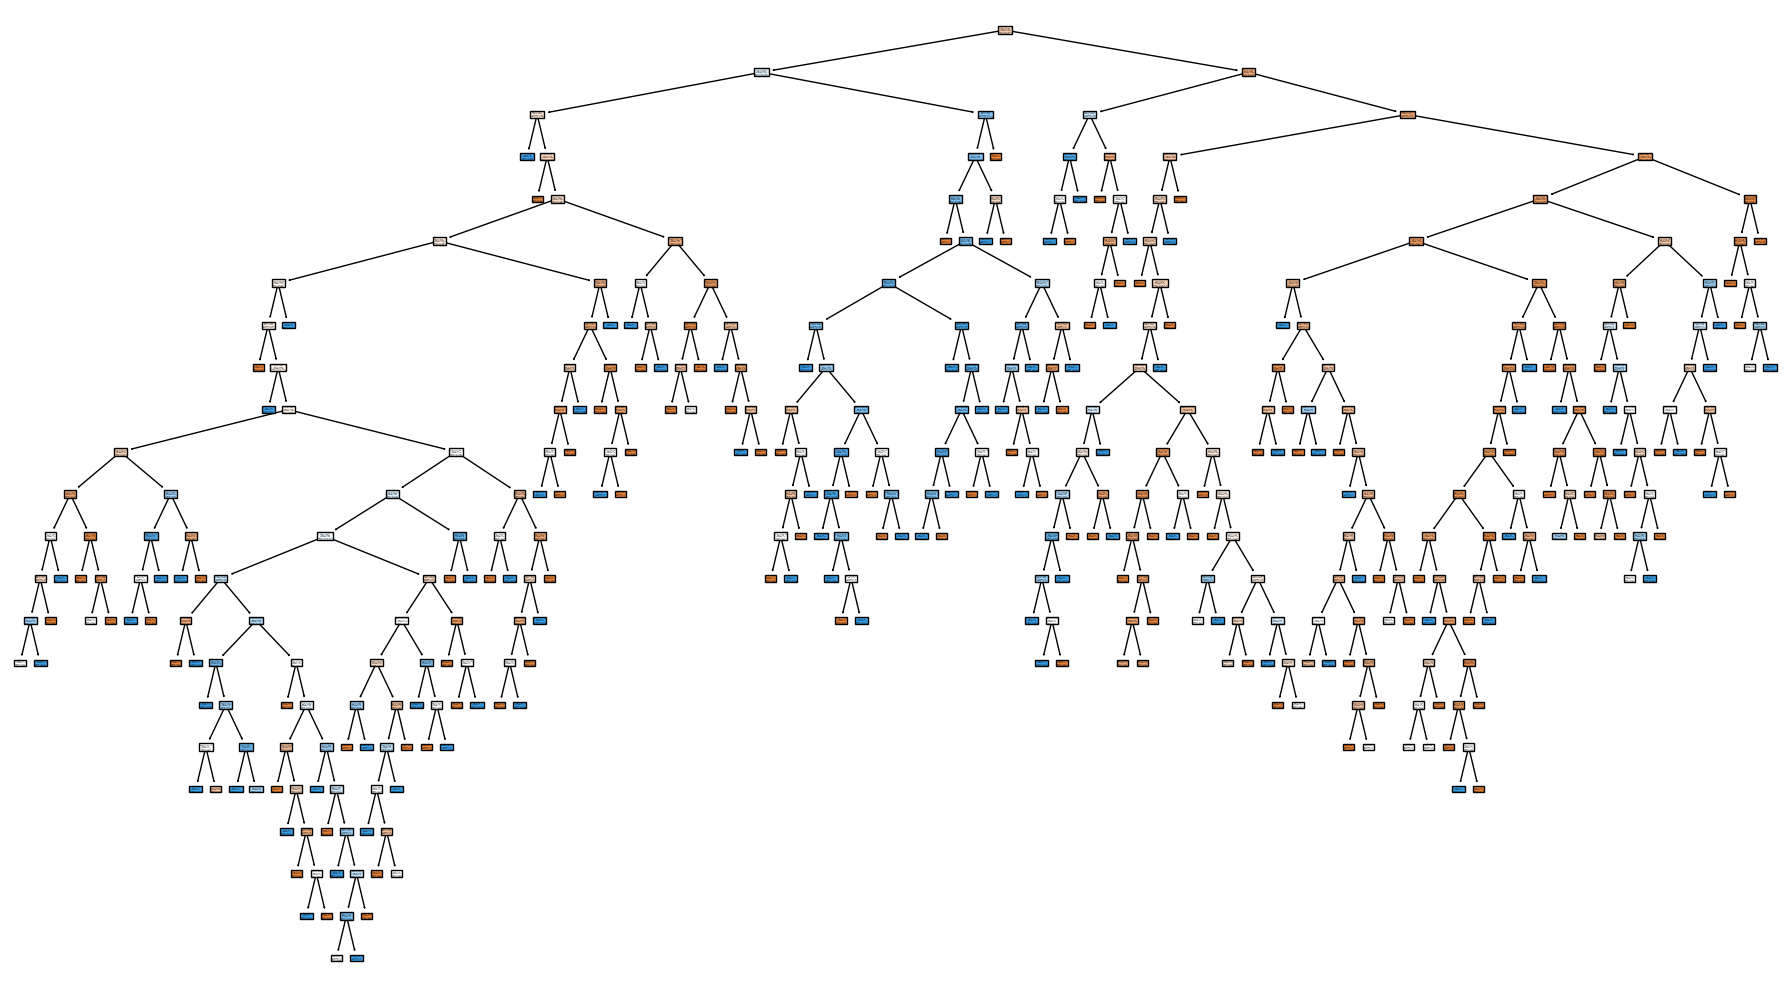

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model , 
    feature_names=X.columns ,
    class_names=["Died" , "Survived"] ,
    filled = True
)
plt.tight_layout()
plt.show()

# Random Forest Classifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=201 , 
    oob_score=True
)
rfc.fit(X_train,y_train)

y_pred = rfc.predict(X_test)

print("OOB score :- ",rfc.oob_score_ *100 ,"%" )
print("testing accuracy :- ",accuracy_score(y_test,y_pred) * 100 , "%")

OOB score :-  67.41573033707866 %
testing accuracy :-  63.43283582089553 %
